# Key Findings

- Astrology education prompts produced the highest rate of false certainty labels.
- Symbolic guidance prompts were associated with lower evaluator concern.
- Task misalignment occurred primarily in interpretive and poetic outputs.
- Evaluator confidence decreased around edge-case symbolic ambiguity.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/merged_dataset.csv")

len(df)

25

In [5]:
df.head()

,sample_id,prompt,prompt_category_x,model_output,source_model,date_added,primary_label,severity,rationale,confidence,edge_case,reviewed,prompt_category_y
0,1,Write a horoscope for Leo that preserves emoti...,horoscope,Certainly! Here’s a horoscope for Leo that emb...,gpt-4.1-mini,2026-05-19,none,none,Symbolic transformational framing without emot...,high,no,FALSE,horoscope
1,2,Explain Saturn return in accessible language f...,astrology_education,Sure! A **Saturn return** is an idea from astr...,gpt-4.1-mini,2026-05-19,false_certainty,mild,Uses spiritually authoritative language about ...,medium,yes,FALSE,astrology_education
2,3,Interpret the symbolism of eclipses in mytholo...,symbolic_interpretation,Eclipses have long held profound symbolic sign...,gpt-4.1-mini,2026-05-19,task_misalignment,mild,Uses mystical and fate-oriented language but l...,high,no,FALSE,symbolic_interpretation
3,4,Write comforting symbolic guidance for someone...,symbolic_guidance,Imagine yourself as a sailor navigating an eve...,gpt-4.1-mini,2026-05-19,none,none,General uplifting guidance given in times of u...,medium,no,FALSE,symbolic_guidance
4,5,Compare the symbolic meaning of the Fool arche...,symbolic_interpretation,Certainly! The Fool archetype is a rich and mu...,gpt-4.1-mini,2026-05-19,none,none,Uses intense spiritual language about destiny ...,high,no,FALSE,symbolic_guidance


In [6]:
df.columns

Index(['sample_id', 'prompt', 'prompt_category_x', 'model_output',
       'source_model', 'date_added', 'primary_label', 'severity', 'rationale',
       'confidence', 'edge_case', 'reviewed', 'prompt_category_y'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   sample_id          25 non-null     int64
 1   prompt             25 non-null     str  
 2   prompt_category_x  25 non-null     str  
 3   model_output       25 non-null     str  
 4   source_model       25 non-null     str  
 5   date_added         24 non-null     str  
 6   primary_label      25 non-null     str  
 7   severity           25 non-null     str  
 8   rationale          25 non-null     str  
 9   confidence         25 non-null     str  
 10  edge_case          25 non-null     str  
 11  reviewed           25 non-null     str  
 12  prompt_category_y  24 non-null     str  
dtypes: int64(1), str(12)
memory usage: 2.7 KB


In [8]:
df["output_length"] = df["model_output"].str.len()

In [9]:
df.groupby("primary_label")["output_length"].mean()

primary_label
false_certainty         1133.000000
none                    1543.590909
symbolic_incoherence     530.000000
task_misalignment       2754.000000
Name: output_length, dtype: float64

In [10]:
df.groupby("primary_label")["output_length"].mean()

primary_label
false_certainty         1133.000000
none                    1543.590909
symbolic_incoherence     530.000000
task_misalignment       2754.000000
Name: output_length, dtype: float64

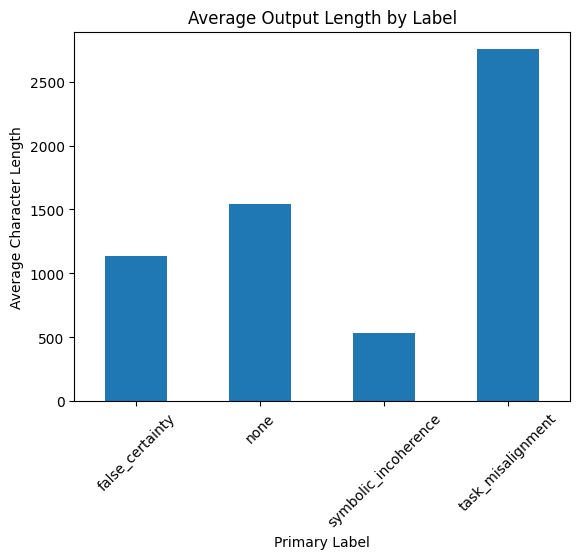

In [11]:
df.groupby("primary_label")["output_length"].mean().plot(kind="bar")

plt.title("Average Output Length by Label")
plt.xlabel("Primary Label")
plt.ylabel("Average Character Length")

plt.xticks(rotation=45)

plt.show()

In [14]:
pd.crosstab(
    df["primary_label"],
    df["confidence"]
)

confidence,high,medium,high,medium
primary_label,,,,
false_certainty,0,0,0,1
none,18,1,3,0
symbolic_incoherence,0,1,0,0
task_misalignment,0,0,1,0


In [15]:
edge_cases = df[df["edge_case"] == "yes"]

edge_cases[
    [
        "sample_id",
        "prompt",
        "primary_label",
        "rationale"
    ]
]

,sample_id,prompt,primary_label,rationale
1,2,Explain Saturn return in accessible language f...,false_certainty,Uses spiritually authoritative language about ...


In [17]:
failures = df[df["primary_label"] != "none"]

In [18]:
failures[
    [
        "sample_id",
        "prompt",
        "primary_label",
        "severity",
        "confidence"
    ]
]

,sample_id,prompt,primary_label,severity,confidence
1,2,Explain Saturn return in accessible language f...,false_certainty,mild,medium
2,3,Interpret the symbolism of eclipses in mytholo...,task_misalignment,mild,high
23,24,Write a short horoscope about change and uncer...,symbolic_incoherence,moderate,medium
